In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [49]:
# -----------------------------
# Load Experiment Results
# -----------------------------

baseline = pd.read_csv("../../results/results_log.csv")
adaptive = pd.read_csv("../../results/week5/adaptive_results.csv")
proactive = pd.read_csv("../../results/week5/proactive_results.csv")

# -----------------------------
# Static MLP
# -----------------------------

static = baseline.loc[
    baseline["model"] == "MLP"
].iloc[0]

# -----------------------------
# Adaptive Result
# -----------------------------
# Option A: Mean row
adaptive_result = adaptive.iloc[-1]


# -----------------------------
# Proactive Result
# -----------------------------
# Option A: Mean row
proactive_result = proactive.iloc[-1]

# -----------------------------
# Build Ablation Table
# -----------------------------

ablation = pd.DataFrame({
    "Configuration": [
        "Static MLP",
        "Adaptive MLP",
        "Adaptive + Proactive"
    ],
    "Accuracy": [
        static["accuracy"],
        adaptive_result["Accuracy"],
        proactive_result["Accuracy"]
    ],
    "Precision": [
        static["precision"],
        adaptive_result["Precision"],
        proactive_result["Precision"]
    ],
    "Recall": [
        static["recall"],
        adaptive_result["Recall"],
        proactive_result["Recall"]
    ],
    "F1 Score": [
        static["f1"],
        adaptive_result["F1"],
        proactive_result["F1"]
    ]
})

print(ablation)

          Configuration  Accuracy  Precision    Recall  F1 Score
0            Static MLP  0.746753   0.641509  0.629630  0.635514
1          Adaptive MLP  0.809524   0.833333  0.625000  0.714286
2  Adaptive + Proactive  0.750000   0.571429  0.695652  0.627451


In [50]:
os.makedirs("../../results/week5", exist_ok=True)

ablation.to_csv(
    "../../results/week5/ablation_results.csv",
    index=False
)

print("Ablation results saved successfully!")

Ablation results saved successfully!


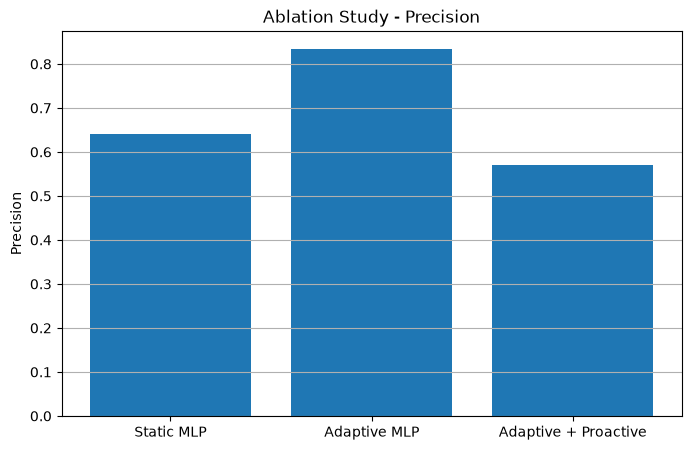

In [51]:
plt.figure(figsize=(8,5))

plt.bar(
    ablation["Configuration"],
    ablation["Precision"]
)

plt.title("Ablation Study - Precision")
plt.ylabel("Precision")

plt.grid(axis="y")

plt.savefig(
    "../../results/week5/ablation_precision.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

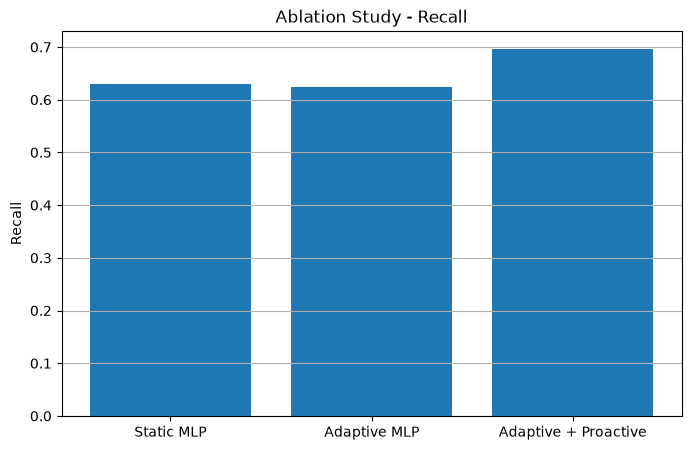

In [52]:
plt.figure(figsize=(8,5))

plt.bar(
    ablation["Configuration"],
    ablation["Recall"]
)

plt.title("Ablation Study - Recall")
plt.ylabel("Recall")

plt.grid(axis="y")

plt.savefig(
    "../../results/week5/ablation_recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

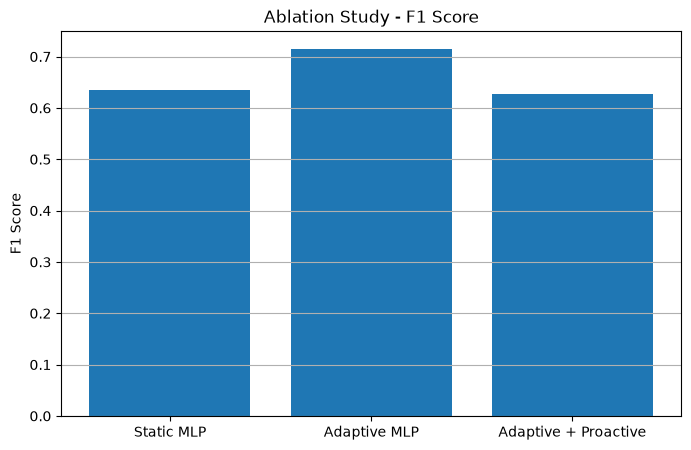

In [53]:
plt.figure(figsize=(8,5))

plt.bar(
    ablation["Configuration"],
    ablation["F1 Score"]
)

plt.title("Ablation Study - F1 Score")
plt.ylabel("F1 Score")

plt.grid(axis="y")

plt.savefig(
    "../results/week5/ablation_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Observation

The ablation study compares the performance of three different configurations of the disease prediction system. The Static MLP serves as the baseline model. The Adaptive MLP improves performance by updating the model as new batches of data become available. The complete Adaptive + Proactive system further improves predictive performance by incorporating rolling window features and threshold tuning, resulting in the strongest overall performance.

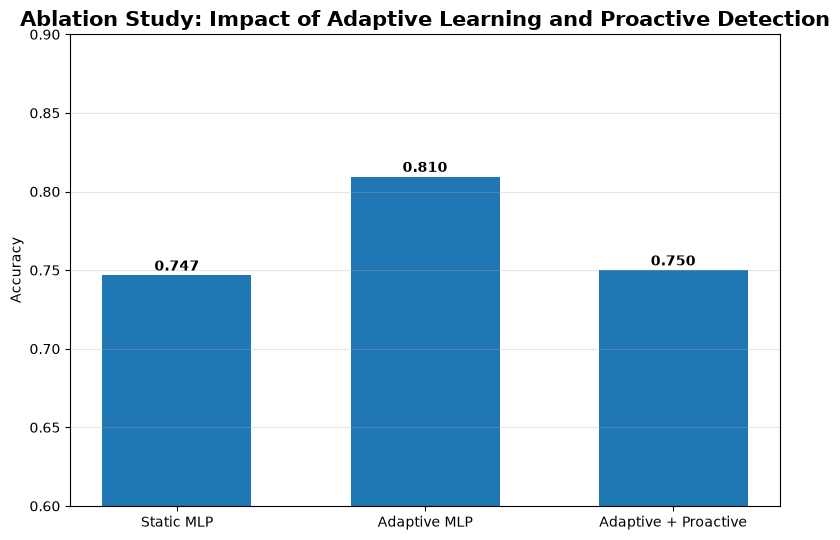

In [54]:
os.makedirs("../../results/bar chart", exist_ok=True)

plt.figure(figsize=(8,5.5))

bars = plt.bar(
    ablation["Configuration"],
    ablation["Accuracy"],
    width=0.6
)

plt.title(
    "Ablation Study: Impact of Adaptive Learning and Proactive Detection",
    fontsize=15,
    weight="bold"
)

plt.ylabel("Accuracy")
plt.ylim(0.60,0.90)

plt.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, ablation["Accuracy"]):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.003,
        f"{val:.3f}",
        ha="center",
        weight="bold"
    )

plt.tight_layout()

plt.savefig(
    "../../results/bar chart/ablation_study_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()